In [32]:
import matplotlib.pyplot as plt
import re
import itertools

In [36]:
def plotreplicas(exp):
    # Parse replicas
    replicas = []
    with open(f"{exp}/watch.log") as f:
        for line in f:
            parts = line.split()
            if parts[0] == "app":
                replicas.append(int(parts[6]))
    
    replicasfix1 = []
    with open(f"flaw1-fix1/{exp}/watch.log") as f:
        for line in f:
            parts = line.split()
            if parts[0] == "app":
                replicasfix1.append(int(parts[6]))
    plt.plot(replicas, color="red", label="Default HPA")
    plt.plot(replicasfix1, color="blue", label="Manual Tuned HPA")
    plt.ylabel("Number Replicas") 
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def plotp99(exp):                
    # Parse vegeta 99th latency (in seconds)
    latencies = []
    files = [f"{exp}/vegeta.1.log", f"{exp}/vegeta.2.log", f"{exp}/vegeta.3.log"]
    lines = itertools.chain.from_iterable(open(f) for f in files)
    for line in lines:
        if line.strip().startswith("Latencies"):
            # format: [mean, 50, 95, 99, max]
            vals = re.findall(r'[\d.]+(?:ms|s|µs|ns)', line)
            p99 = vals[3]
            if p99.endswith("ms"):
                latencies.append(float(p99[:-2]) / 1000)
            elif p99.endswith("µs"):
                latencies.append(float(p99[:-2]) / 1e6)
            elif p99.endswith("ns"):
                latencies.append(float(p99[:-2]) / 1e9)
            else:
                latencies.append(float(p99[:-1]))
                
    latenciesfix1 = []
    files = [f"flaw1-fix1/{exp}/vegeta.1.log", f"flaw1-fix1/{exp}/vegeta.2.log", f"flaw1-fix1/{exp}/vegeta.3.log"]
    lines = itertools.chain.from_iterable(open(f) for f in files)
    for line in lines:
        if line.strip().startswith("Latencies"):
            # format: [mean, 50, 95, 99, max]
            vals = re.findall(r'[\d.]+(?:ms|s|µs|ns)', line)
            p99 = vals[3]
            if p99.endswith("ms"):
                latenciesfix1.append(float(p99[:-2]) / 1000)
            elif p99.endswith("µs"):
                latenciesfix1.append(float(p99[:-2]) / 1e6)
            elif p99.endswith("ns"):
                latenciesfix1.append(float(p99[:-2]) / 1e9)
            else:
                latenciesfix1.append(float(p99[:-1]))
                
    plt.plot(latencies, color="red", label="Default HPA")
    plt.plot(latenciesfix1, color="blue", label="Manual Tuned HPA")
    plt.ylabel("P99 Latency (s)") 
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def plot(exp):
    # Parse replicas
    replicas = []
    with open(f"{exp}/watch.log") as f:
        for line in f:
            parts = line.split()
            if parts[0] == "app":
                replicas.append(int(parts[6]))
    
    replicasfix1 = []
    with open(f"flaw1-fix1/{exp}/watch.log") as f:
        for line in f:
            parts = line.split()
            if parts[0] == "app":
                replicasfix1.append(int(parts[6]))

    # Parse vegeta 99th latency (in seconds)
    latencies = []
    files = [f"{exp}/vegeta.1.log", f"{exp}/vegeta.2.log", f"{exp}/vegeta.3.log"]
    lines = itertools.chain.from_iterable(open(f) for f in files)
    for line in lines:
        if line.strip().startswith("Latencies"):
            # format: [mean, 50, 95, 99, max]
            vals = re.findall(r'[\d.]+(?:ms|s|µs|ns)', line)
            p99 = vals[3]
            if p99.endswith("ms"):
                latencies.append(float(p99[:-2]) / 1000)
            elif p99.endswith("µs"):
                latencies.append(float(p99[:-2]) / 1e6)
            elif p99.endswith("ns"):
                latencies.append(float(p99[:-2]) / 1e9)
            else:
                latencies.append(float(p99[:-1]))
                
    latenciesfix1 = []
    files = [f"flaw1-fix1/{exp}/vegeta.1.log", f"flaw1-fix1/{exp}/vegeta.2.log", f"flaw1-fix1/{exp}/vegeta.3.log"]
    lines = itertools.chain.from_iterable(open(f) for f in files)
    for line in lines:
        if line.strip().startswith("Latencies"):
            # format: [mean, 50, 95, 99, max]
            vals = re.findall(r'[\d.]+(?:ms|s|µs|ns)', line)
            p99 = vals[3]
            if p99.endswith("ms"):
                latenciesfix1.append(float(p99[:-2]) / 1000)
            elif p99.endswith("µs"):
                latenciesfix1.append(float(p99[:-2]) / 1e6)
            elif p99.endswith("ns"):
                latenciesfix1.append(float(p99[:-2]) / 1e9)
            else:
                latenciesfix1.append(float(p99[:-1]))

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.set_xlabel("Time (samples)")
    ax1.set_ylabel("Replicas", color="tab:blue")
    ax1.plot(replicas, color="tab:blue", label="Replicas")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.set_ylabel("P99 Latency Flaw 1(s)", color="tab:red")
    ax2.plot(latencies, color="tab:red", label="P99 Latency")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax2.set_ylim(top=0.225)
    
    ax3 = ax1.twinx()
    #ax3.set_ylabel("P99 Latency Flaw 1 Fix 1(s)", color="tab:blue")
    ax3.plot(latenciesfix1, color="tab:green", label="P99 Latency Fix")
    ax3.set_ylim(top=0.225)
    #ax3.tick_params(axis="y", labelcolor="tab:blue")

    plt.title("Replicas vs P99 Latency (show delayed reaction from HPA)")
    fig.tight_layout()
    fig.show()

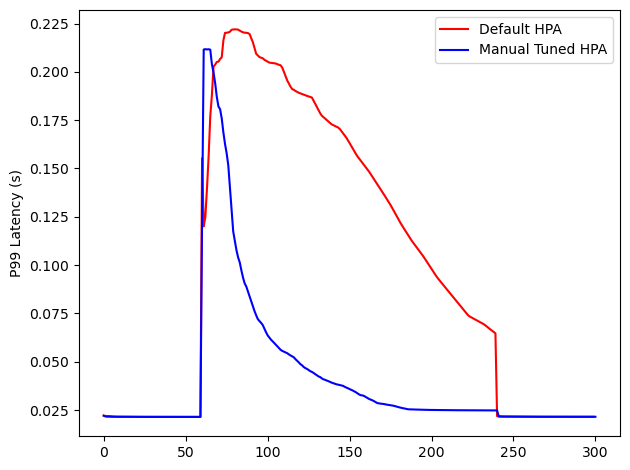

In [37]:
plotp99("experiment_run_1")

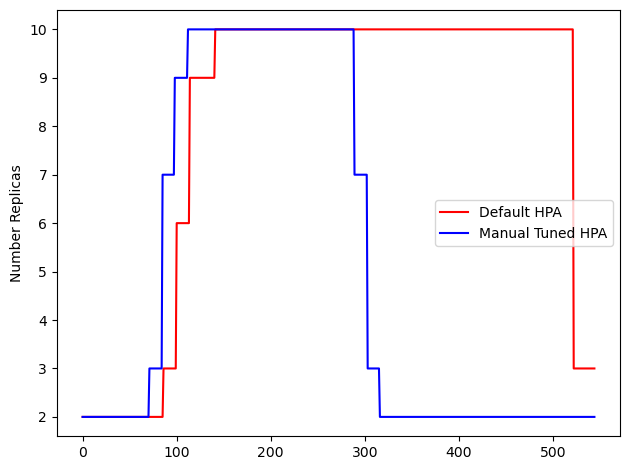

In [38]:
plotreplicas("experiment_run_1")

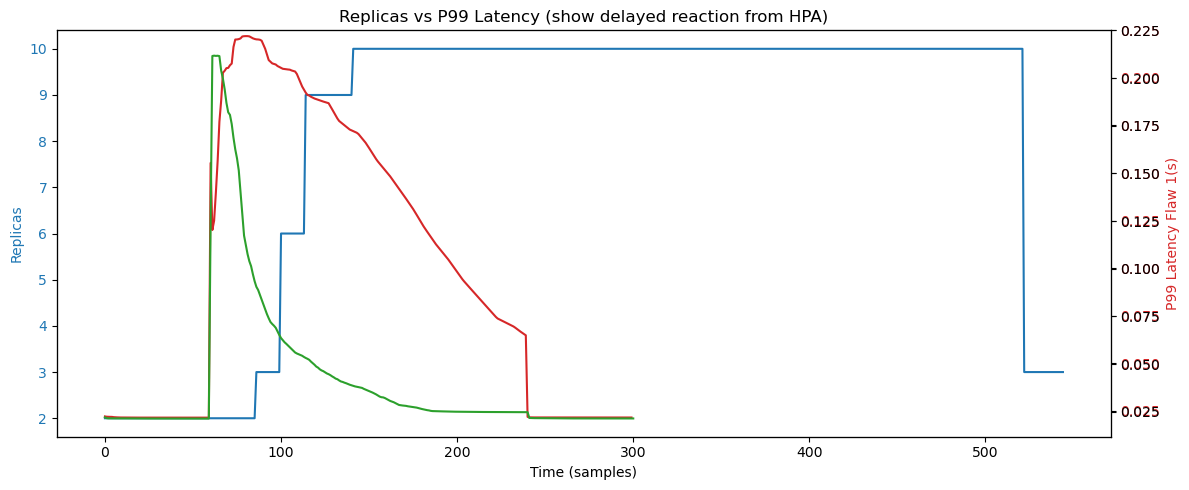

In [24]:
plot("experiment_run_1")


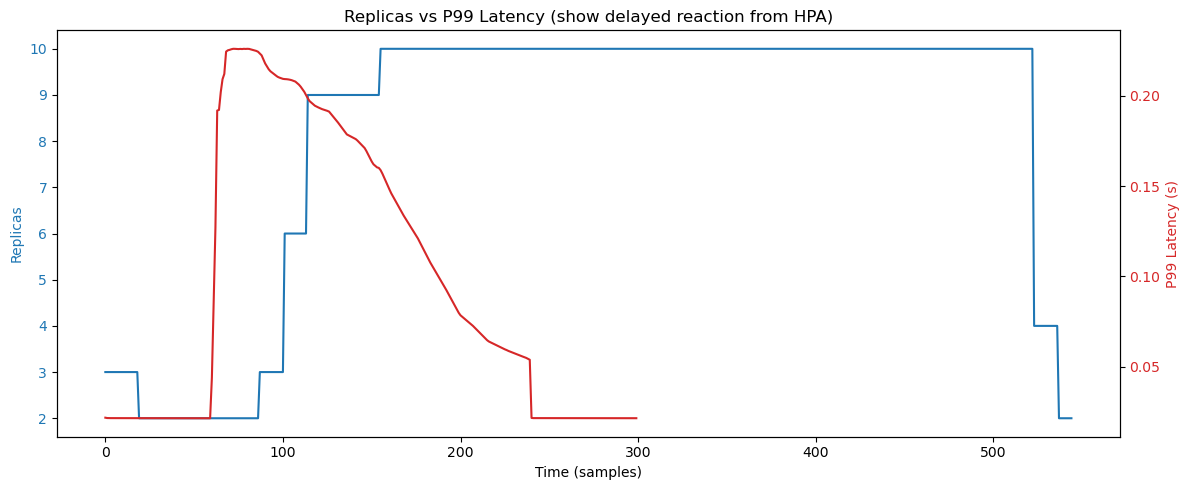

In [4]:
plot("experiment_run_2")


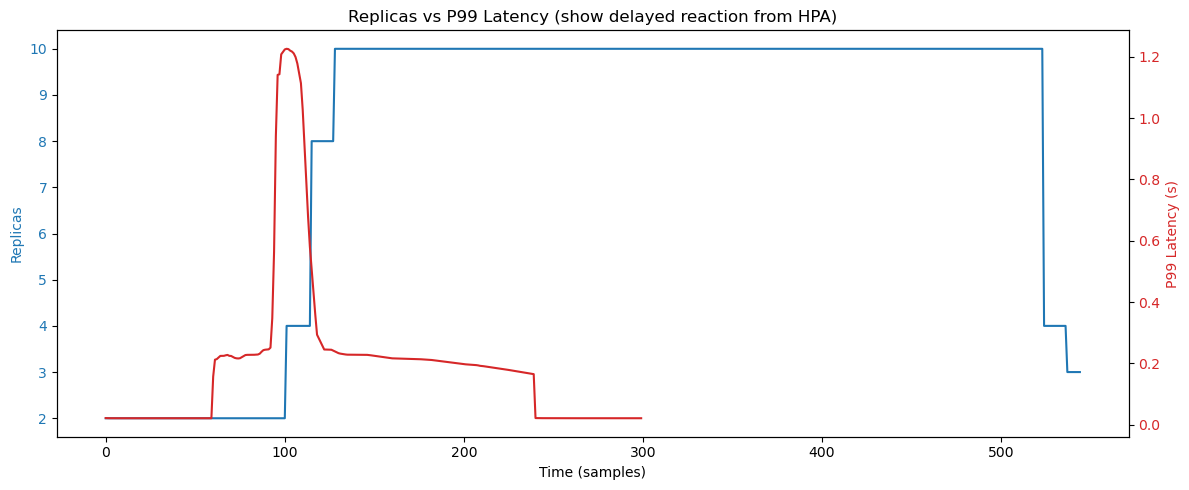

In [5]:
plot("experiment_run_3")
